# SAMap mapping summary

## tl;dr

The official three-species SAMap run identifies several interpretable
cross-species candidates. The strongest mapping is Pristina
**anterior/mid-intestine 2 → zebrafish LRE** (score 0.762). Scores are
similarities, not probabilities or identity calls.

## Context & Methods

This notebook reads the compact public export generated after the
completed SAMap run. `top_score` is the highest cell-type mapping score
for a Pristina population and a comparison species. `score_margin` is
the difference between its best and second-best counterpart and is a
descriptive measure of mapping specificity.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "public_results").exists():
    ROOT = ROOT.parent
PUBLIC = ROOT / "public_results"

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Data

In [2]:
summary = pd.read_csv(PUBLIC / "pristina_cross_species_summary.csv")
summary.sort_values(["comparison_species", "top_score"], ascending=[True, False]).head(10)

,pristina_cell_type,comparison_species,top_match,top_score,second_match,second_score,score_margin,specificity_class
0,stomach 2,human,Colonocyte,0.592689,TA,0.028946,0.563743,higher specificity
1,anterior intestine,human,Enterocyte,0.444796,Paneth,0.238274,0.206522,higher specificity
2,stomach 1,human,Tuft,0.418874,TA,0.318060,0.100814,moderate specificity
3,anterior/mid-intestine 2,human,Paneth,0.377292,BEST4+ epithelial,0.076524,0.300768,higher specificity
4,crop,human,Goblet cell,0.238789,BEST2+ Goblet cell,0.162807,0.075981,moderate specificity
5,gut progenitors,human,TA,0.234643,Stem cells,0.192215,0.042428,ambiguous
6,anterior/mid-intestine 1,human,EC cells (TAC1+),0.226382,Paneth,0.223380,0.003002,ambiguous
7,posterior intestine,human,BEST2+ Goblet cell,0.118722,Paneth,0.092516,0.026205,ambiguous
8,caveolin+ cells,human,BEST2+ Goblet cell,0.114396,Goblet cell,0.066860,0.047536,ambiguous
9,anterior/mid-intestine 2,zebrafish,LRE,0.762155,Tuft-like,0.030704,0.731451,higher specificity


## Results

In [3]:
display_columns = [
    "pristina_cell_type", "comparison_species", "top_match",
    "top_score", "second_match", "score_margin", "specificity_class",
]
summary[display_columns].sort_values("top_score", ascending=False)

,pristina_cell_type,comparison_species,top_match,top_score,second_match,score_margin,specificity_class
9,anterior/mid-intestine 2,zebrafish,LRE,0.762155,Tuft-like,0.731451,higher specificity
0,stomach 2,human,Colonocyte,0.592689,TA,0.563743,higher specificity
10,anterior/mid-intestine 1,zebrafish,EC,0.451394,Pancreatic,0.127567,moderate specificity
1,anterior intestine,human,Enterocyte,0.444796,Paneth,0.206522,higher specificity
2,stomach 1,human,Tuft,0.418874,TA,0.100814,moderate specificity
3,anterior/mid-intestine 2,human,Paneth,0.377292,BEST4+ epithelial,0.300768,higher specificity
11,stomach 1,zebrafish,T Cell,0.345373,Best4/Otop2,0.017327,ambiguous
12,anterior intestine,zebrafish,EC,0.312822,LRE,0.058031,moderate specificity
13,posterior intestine,zebrafish,Goblet-like,0.276361,Epidermal,0.052466,moderate specificity
4,crop,human,Goblet cell,0.238789,BEST2+ Goblet cell,0.075981,moderate specificity


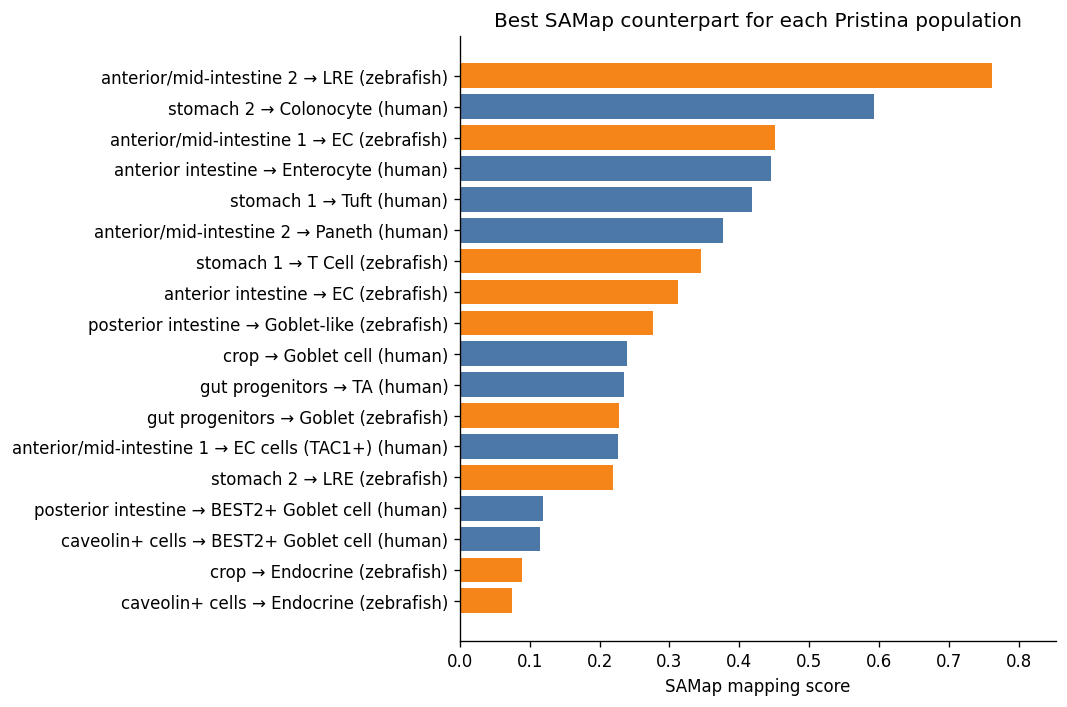

In [4]:
plot_data = summary.sort_values("top_score")
colors = plot_data["comparison_species"].map({"human": "#4C78A8", "zebrafish": "#F58518"})
labels = plot_data["pristina_cell_type"] + " → " + plot_data["top_match"] + " (" + plot_data["comparison_species"] + ")"

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels, plot_data["top_score"], color=colors)
ax.set_xlabel("SAMap mapping score")
ax.set_title("Best SAMap counterpart for each Pristina population")
ax.set_xlim(0, max(plot_data["top_score"]) * 1.12)
fig.tight_layout()
plt.show()

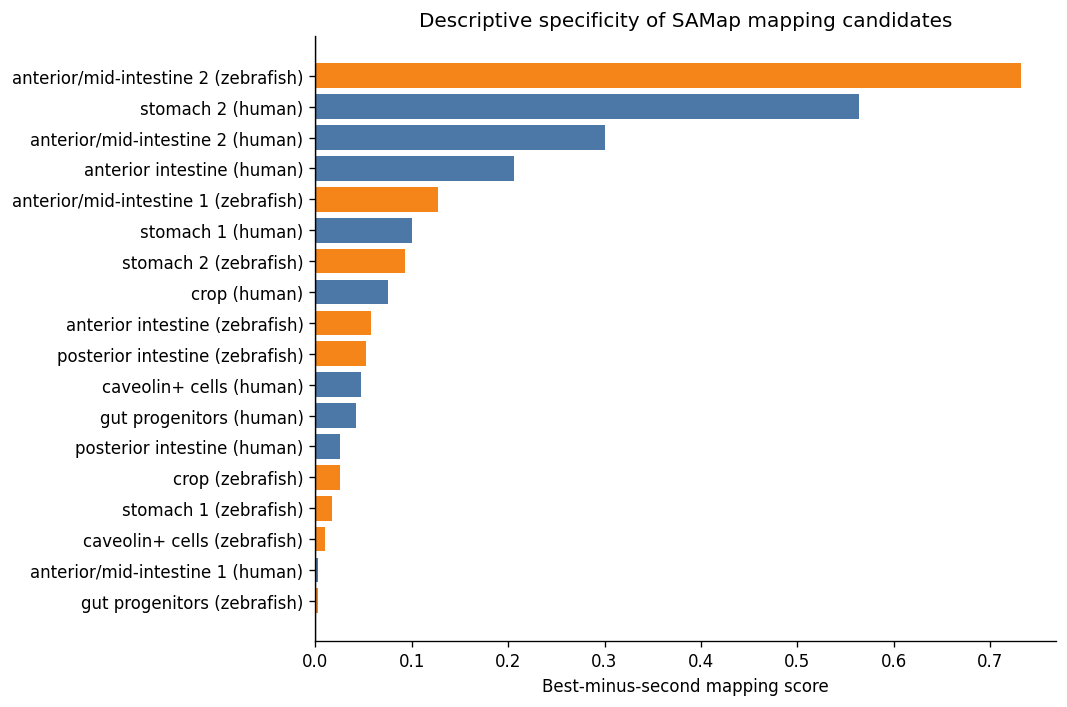

In [5]:
margin_data = summary.sort_values("score_margin")
colors = margin_data["comparison_species"].map({"human": "#4C78A8", "zebrafish": "#F58518"})
labels = margin_data["pristina_cell_type"] + " (" + margin_data["comparison_species"] + ")"

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(labels, margin_data["score_margin"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Best-minus-second mapping score")
ax.set_title("Descriptive specificity of SAMap mapping candidates")
fig.tight_layout()
plt.show()

## Takeaways

- **Anterior/mid-intestine 2 → zebrafish LRE** has the highest mapping
  score and the largest margin in this comparison.
- **Stomach 2 → human colonocyte** and **anterior intestine → human
  enterocyte** are useful hypotheses, but marker-level evidence is
  needed before assigning biological labels.
- Low score margins indicate ambiguity; they should not be presented as
  one-to-one homologous cell types.